In [ ]:
!pip install librosa soundfile

In [ ]:
#Mounting drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_PATH = "/content/drive/MyDrive/ml_project/data/ravdess"

In [ ]:
import os
import numpy as np
import librosa
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models

In [ ]:
import random

def augment_audio(y, sr):
    # Add noise
    noise = np.random.randn(len(y))
    y = y + 0.005 * noise

    # Pitch shift (random)
    if random.random() > 0.5:
        y = librosa.effects.pitch_shift(y, sr=sr, n_steps=random.randint(-2,2))

    return y

In [ ]:
##Create Mel Spectrogram Dataset
EMOTION_MAP = {
    '01': 0, '02': 1, '03': 2, '04': 3,
    '05': 4, '06': 5, '07': 6, '08': 7
}

def extract_mel_spectrogram(file_path, max_len=130, augment=False):
    y, sr = librosa.load(file_path, sr=16000)

    # Apply augmentation
    if augment and random.random() > 0.7:
        noise = np.random.randn(len(y))
        y = y + 0.005 * noise

        if random.random() > 0.5:
            y = librosa.effects.pitch_shift(y, sr=sr, n_steps=random.randint(-2,2))

    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # GUARANTEED FIXED SHAPE
    if mel_db.shape[1] < max_len:
        pad_width = max_len - mel_db.shape[1]
        mel_db = np.pad(mel_db, ((0,0),(0,pad_width)), mode='constant')
    else:
        mel_db = mel_db[:, :max_len]

    return mel_db

In [ ]:
def load_data(data_path):
    X, y = [], []

    files = []
    for root, _, filenames in os.walk(data_path):
        for f in filenames:
            if f.endswith(".wav"):
                files.append(os.path.join(root, f))

    print("Total files:", len(files))

    for file in tqdm(files):
        try:
            mel = extract_mel_spectrogram(file, augment=True)

            label = file.split("/")[-1].split("-")[2]
            label = EMOTION_MAP[label]

            X.append(mel)
            y.append(label)

        except Exception as e:
            print("Error:", e)
            continue

    return np.array(X), np.array(y)

X, y = load_data(DATA_PATH)

print(X.shape)  # should be (1440, 128, 130)
print(set([x.shape for x in X]))

Total files: 1440


100%|██████████| 1440/1440 [00:40<00:00, 35.64it/s]


(1440, 128, 130)
{(128, 130)}


In [ ]:
# Normalize
X = (X - X.mean()) / X.std()

# Add channel dimension
X = X[..., np.newaxis]

print(X.shape)  # (1440, 128, 130, 1)

(1440, 128, 130, 1)


In [ ]:
##saving X,y as the loading function takes much time in collab ..(normalized X and y)

np.save("X_mel.npy", X)
np.save("y.npy", y)

##ALSO saving mean and std
mean = X.mean()
std = X.std()

np.save("norm_mean.npy", mean)
np.save("norm_std.npy", std)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:


model = models.Sequential([

    # CNN feature extractor
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,130,1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Convert to sequence
    layers.Reshape((-1, 128)),   # 👈 KEY STEP

    # BiLSTM
    layers.Bidirectional(layers.LSTM(64, return_sequences=False)),

    # Dense
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(8, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 126, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 126, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 63, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 61, 62, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 61, 62, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 30, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 29, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 28, 29, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 196, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 201,160 (785.78 KB)

 Trainable params: 200,712 (784.03 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
##Train Model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32
)

Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 93ms/step - accuracy: 0.1944 - loss: 2.0324 - val_accuracy: 0.1169 - val_loss: 2.0581
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.2682 - loss: 1.8873 - val_accuracy: 0.1126 - val_loss: 2.0582
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.3333 - loss: 1.7799 - val_accuracy: 0.1126 - val_loss: 2.1833
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.3312 - loss: 1.7607 - val_accuracy: 0.1039 - val_loss: 2.2313
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.3941 - loss: 1.6334 - val_accuracy: 0.1039 - val_loss: 2.4267
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.3974 - loss: 1.5496 - val_accuracy: 0.1082 - val_loss: 2.4194
Epoch 7/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.4354 - loss: 1.4932 - val_accuracy: 0.1126 - val_loss: 2.4397
Epoch 8/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.4376 - loss: 1.4638 - val_accuracy: 0.1299 - 

In [ ]:
##Below code with some improvements i.e with callback

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt


In [ ]:
##Callbacks setup
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_accuracy',
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

In [ ]:
##train_with_callbacks
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping, model_checkpoint, reduce_lr]
)

Epoch 1/30
28/29 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9628 - loss: 0.1373

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.9544 - loss: 0.1604 - val_accuracy: 0.4935 - val_loss: 1.9363 - learning_rate: 0.0010
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.9598 - loss: 0.1473 - val_accuracy: 0.4848 - val_loss: 1.8518 - learning_rate: 0.0010
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.9805 - loss: 0.0956 - val_accuracy: 0.4416 - val_loss: 2.5217 - learning_rate: 0.0010
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.9783 - loss: 0.0876 - val_accuracy: 0.4848 - val_loss: 2.2213 - learning_rate: 0.0010
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.9837 - loss: 0.0752 - val_accuracy: 0.4935 - val_loss: 2.2806 - learning_rate: 0.0010
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9925 - loss: 0.0442

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.9881 - loss: 0.0544 - val_accuracy: 0.5152 - val_loss: 2.0652 - learning_rate: 5.0000e-04
Epoch 7/30
28/29 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9868 - loss: 0.0385

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.9913 - loss: 0.0409 - val_accuracy: 0.5238 - val_loss: 2.0617 - learning_rate: 5.0000e-04


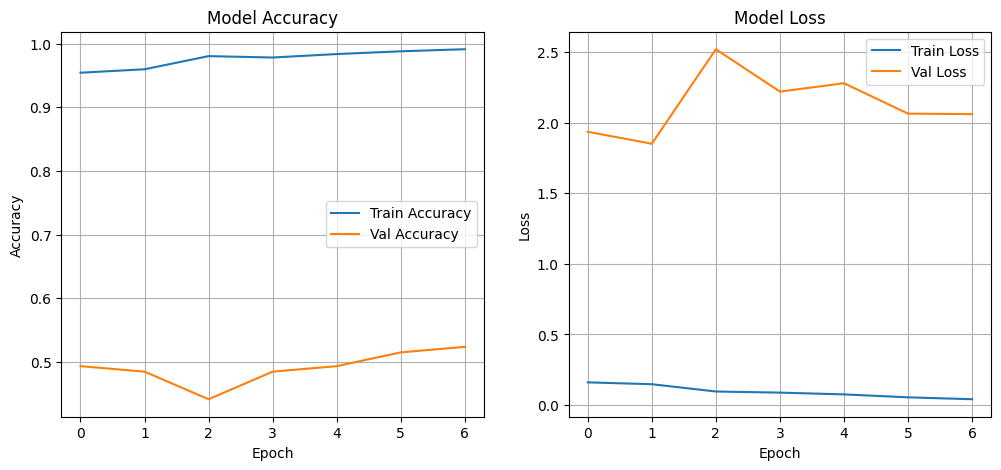

In [ ]:

# Accuracy plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


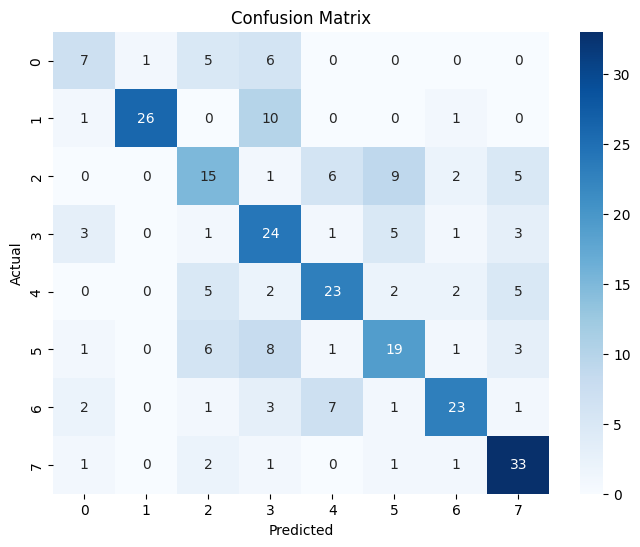

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = model.predict(X_test)
y_pred_classes = y_pred.argmax(axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
model.save("final_model.h5")

np.save("X_test.npy", X_test)
np.save("y_test.npy", y_test)

In [ ]:
##Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_acc)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5903 - loss: 1.5518
Test Accuracy: 0.5902777910232544
